# Imports and Project setup


In [ ]:
from pathlib import Path

from dotenv import load_dotenv
from langchain_core.documents import Document

from utils import clean_and_convert_html_2_markdown
from chunker import ContextualChunker
from vectorstore import WeaviateStore
from agent import Agent

load_dotenv()

HTML_DIR = Path("data/html")
DATA_DIR = Path("data")


# Adobe 10-K Document Loader

Load HTML files from `data/html/`, clean with BeautifulSoup, convert to markdown.

> **Assumption:** No dataset was provided by Adobe, so I used publicly available Adobe 10-K annual filings (fiscal years 2022–2025) from SEC EDGAR. The raw HTML files are committed to this repo for review.

**PDF → HTML pivot:** I initially tried extracting text from the PDF versions of these filings using PyMuPDF/pymupdf4llm, but the output was garbled, SEC PDFs use custom font encodings that break standard text extraction. An OCR-based fallback would have been significantly slower. Since SEC EDGAR also serves the original HTML filings, I switched to downloading those directly. HTML is the native filing format, so the conversion to markdown is lossless, fast, and requires no OCR.


In [ ]:
html_files = sorted(HTML_DIR.glob("*.html"))
print(f"Found {len(html_files)} HTML files: {[f.name for f in html_files]}")


Found 4 HTML files: ['adobe_10k_fy2022.html', 'adobe_10k_fy2023.html', 'adobe_10k_fy2024.html', 'adobe_10k_fy2025.html']


In [ ]:
for html_file in html_files:
    md_filename = html_file.stem + ".md"
    md_filepath = DATA_DIR / md_filename

    raw_html = html_file.read_text(encoding="utf-8")
    markdown = clean_and_convert_html_2_markdown(raw_html)

    md_filepath.write_text(markdown, encoding="utf-8")
    print(f"{html_file.name} -> {md_filename} ({len(markdown):,} characters)")


# Preview a sample from one of the converted files
sample = Path("data/adobe_10k_fy2024.md").read_text(encoding="utf-8")
print(f"\n\nSample:\n{sample[20_000:21_000]}")


adobe_10k_fy2022.html -> adobe_10k_fy2022.md (397,559 characters)
adobe_10k_fy2023.html -> adobe_10k_fy2023.md (392,649 characters)
adobe_10k_fy2024.html -> adobe_10k_fy2024.md (403,098 characters)
adobe_10k_fy2025.html -> adobe_10k_fy2025.md (371,252 characters)


Sample:
ve, interactive tutorials with creators. Additionally, with Adobe GenStudio and Adobe GenStudio for Performance Marketing, a generative AI-first product that natively integrates Digital Media and Digital Experience offerings, we help enterprises to quickly create on-brand content variations and accelerate their marketing workflows. Further descriptions of our Digital Media products are included below under “Principal Products, Services and Solutions.”

In our Creative Cloud business, we employ our product-led growth strategy to minimize the friction of customer interactions and drive positive product experiences, which results in increasing adoption, usage, conversion, expansion and loyalty. We also continue to emplo

# Contextual Chunking

Split the cleaned markdown documents into token-based chunks and enrich each chunk with LLM-generated context.

> **Note:** The LLM-generated context cache (`data/.chunk_cache/cache.json`) is committed to this repo. On subsequent runs the chunker loads contexts from cache instantly, no LLM calls are made unless new or changed chunks are detected.

#### Why contextual chunking?

Financial data is highly dependent on surrounding context. A plain recursive split can produce chunks like:

> _"Creative revenue of $12.68 billion during fiscal 2024 increased by $1.17 billion, or 10% … Document Cloud revenue of $3.18 billion increased by $483 million, or 18% …"_

This chunk never mentions **"Adobe"**, the company name simply wasn't in the split window. A query like _"Adobe Document Cloud revenue growth"_ gets a weak embedding match because the key term is missing. Contextual enrichment prepends a short LLM-generated summary (company name, fiscal year, what the surrounding text discusses) so the embedding captures the full meaning and retrieval accuracy improves significantly.

For the chunk above, the generated context looks like:

> _`[Chunk_Context_Start]` The preceding text discussed Adobe's ongoing improvements and new features in its Digital Media products, including web-based versions of Photoshop and Illustrator, 3D content creation tools, and community engagement initiatives. This chunk continues by detailing **Adobe's** product-led growth and data-driven strategies for its **Creative Cloud** and **Document Cloud** businesses, focusing on customer acquisition, retention, and revenue growth for **fiscal year 2023**. `[Chunk_Context_End]`_

The context injects "Adobe", "Creative Cloud", "Document Cloud", and "fiscal year 2023" directly into the chunk text before embedding, terms the raw chunk was missing entirely.


In [ ]:
# Load markdown files as LangChain Documents
md_files = sorted(Path("data").glob("adobe_10k_*.md"))
documents = []
for md_file in md_files:
    text = md_file.read_text(encoding="utf-8")
    documents.append(Document(page_content=text, metadata={"source": md_file.name}))

print(f"Loaded {len(documents)} documents")

# Chunk with context
chunker = ContextualChunker(chunk_size=1024, chunk_overlap=128)
chunks = chunker.chunk(documents)

print(f"\nTotal chunks: {len(chunks)}")
print(f"\nSample chunk (index 50):\n{'=' * 60}")
print(chunks[50].page_content[:600])


Loaded 4 documents
  [418/418] processed (cache hits: 418)
Done: 418 chunks (418 from cache, 0 generated).

Total chunks: 418

Sample chunk (index 50):
[Chunk_Context_Start]The preceding text discussed the company's stock repurchase program, including the authority granted by the Board of Directors to repurchase shares and the rationale behind the program, as well as recent legislative tax changes that could impact the company. This chunk provides a detailed account of the company's (likely Adobe's, based on context) stock repurchase activities during fiscal 2022, including the number of shares repurchased, the financial arrangements involved, and references to further details in other sections of the report. It also addresses the company's i


In [ ]:
store = WeaviateStore(collection_name="Adobe10K")
store.ingest(chunks)

print("Collection ready. Testing search...")
results = store.search("What was Adobe's total revenue in fiscal year 2024?")
for i, r in enumerate(results):
    print(f"\n--- Result {i + 1} (source: {r['source']}) ---")
    print(r["content"][:300])


Collection already has 418 objects — skipping ingestion.
Collection ready. Testing search...

--- Result 1 (source: adobe_10k_fy2024.md) ---
[Chunk_Context_Start]The preceding text discussed Adobe's strong revenue growth across its Creative and Document Cloud segments, highlighting year-over-year increases and introducing the Digital Experience segment as a key area of market leadership and innovation, particularly through AI integration

--- Result 2 (source: adobe_10k_fy2024.md) ---
[Chunk_Context_Start]The preceding text provided a summary of Adobe's financial performance for fiscal year 2024, highlighting key metrics such as annual recurring revenue, segment revenues, cost of revenue, and operating expenses. This chunk continues the financial overview by detailing Adobe's net

--- Result 3 (source: adobe_10k_fy2024.md) ---
[Chunk_Context_Start]The preceding text presented a table summarizing Adobe's subscription revenue by segment for fiscal years 2022, 2023, and 2024, highlighting

# Agent Demo

Initialize the agent with the same vector store used for ingestion.

**Design decisions:**

- **No LangGraph / heavy framework:** This is a focused test prototype, not a production multi-agent system. A full LangGraph setup would add unnecessary complexity for a single-agent, tool-calling workflow. Instead, a lightweight custom agent loop handles tool dispatch directly.
- **Tools defined inside the Agent class:** Rather than using a tool decorator pattern (e.g. `@tool`), all tools and their OpenAI-function schemas are declared within the `Agent` class itself. This keeps the agent self-contained and easy to reason about, an acceptable trade-off for a task of this scope.


In [ ]:
agent = Agent(store=store)


### Example 1: "What is our current revenue trend?"

_(From challenge document)_


In [22]:
print(agent.run("What is our current revenue trend?"))


  [Tool] retrieve_chunks({"query": "Adobe total revenue by fiscal year 2022, 2023, 2024", "limit": 5})
Adobe's current revenue trend shows consistent year-over-year growth. Here are the total revenues for the past three fiscal years:

- Fiscal 2022: $17.61 billion
- Fiscal 2023: $19.41 billion
- Fiscal 2024: $21.51 billion

This represents an 11% increase from 2023 to 2024, and a 10% increase from 2022 to 2023. The growth is primarily driven by strong performance in the Digital Media and Digital Experience segments.

(Source: adobe_10k_fy2024.md)


### Example 2: "Which departments are underperforming?"

_(From challenge document)_


In [23]:
print(agent.run("Which departments or segments are underperforming?"))


  [Tool] retrieve_chunks({"query": "underperforming departments or segments"})
  [Tool] retrieve_chunks({"query": "Adobe segment revenue and growth rates fiscal 2025, 2024, 2023"})
Based on Adobe's most recent SEC 10-K filings (fiscal years 2023–2025), the underperforming segment is the Publishing and Advertising segment. Here’s a summary of segment performance:

- Digital Media: Continues to be the largest and fastest-growing segment, with revenue increasing from $14.22 billion in 2023 to $15.86 billion in 2024 (up 12%), and to $17.65 billion in 2025 (up 11%). This segment consistently represents about 74% of total revenue.
- Digital Experience: Also shows steady growth, with revenue rising from $4.89 billion in 2023 to $5.37 billion in 2024 (up 10%), and to $5.86 billion in 2025 (up 9%). This segment accounts for about 25% of total revenue.
- Publishing and Advertising: This is Adobe’s smallest and only declining segment. Revenue decreased from $300 million in 2023 to $275 million in

### Example 3: "What were the key risks highlighted in the last quarter?"

_(From challenge document)_


In [24]:
print(agent.run("What were the key risks highlighted in the most recent fiscal year?"))


  [Tool] retrieve_chunks({"query": "key risks highlighted in the most recent fiscal year"})
The key risks highlighted in Adobe's most recent fiscal year (2023, as reported in the FY2024 10-K) include:

1. Subscription-Based Revenue Model: Changes in subscription or renewal rates may not be immediately reflected in revenue due to the ratable recognition of subscription revenue. Lower sales, reduced demand, or increased attrition may impact future financial results. (source: adobe_10k_fy2024.md)

2. Foreign Currency Fluctuations: Adobe is exposed to risks from global currency exchange rate changes, which may not be fully offset by hedging activities and could adversely affect reported financial results. (source: adobe_10k_fy2024.md)

3. Impairment of Goodwill and Intangible Assets: If goodwill or intangible assets become impaired, Adobe could be required to record significant charges, negatively impacting earnings. (source: adobe_10k_fy2024.md)

4. Debt Obligations: Existing and future d

---

### Complex Example 1: Multi-metric bar chart with query decomposition

_Agent decomposes the query into multiple retrievals, extracts data, and creates a chart._


  [Tool] retrieve_chunks({"query": "Adobe total revenue fiscal years 2022, 2023, 2024, 2025", "limit": 4})
  [Tool] retrieve_chunks({"query": "Adobe operating cash flow fiscal years 2022, 2023, 2024, 2025", "limit": 4})
  [Tool] retrieve_chunks({"query": "Adobe capital expenditures (capex) fiscal years 2022, 2023, 2024, 2025", "limit": 4})
  [Tool] retrieve_chunks({"query": "Adobe capital expenditures (capex) fiscal years 2022, 2023, 2024, 2025", "limit": 4})
  [Tool] retrieve_chunks({"query": "Adobe purchases of property and equipment (capital expenditures) fiscal years 2022, 2023, 2024, 2025", "limit": 4})
  [Tool] create_chart({"chart_type": "bar", "title": "Adobe Revenue, Operating Cash Flow, and Capex (2022-2025)", "labels": ["2022", "2023", "2024", "2025"], "datasets": [{"name": "Revenue", "values": [17606, 19409, 21505, 23769]}, {"name": "Operating Cash Flow", "values": [7838, 7302, 8056, 10031]}, {"name": "Capex", "values": [442, 360, 183, 179]}], "y_label": "$ Millions"})


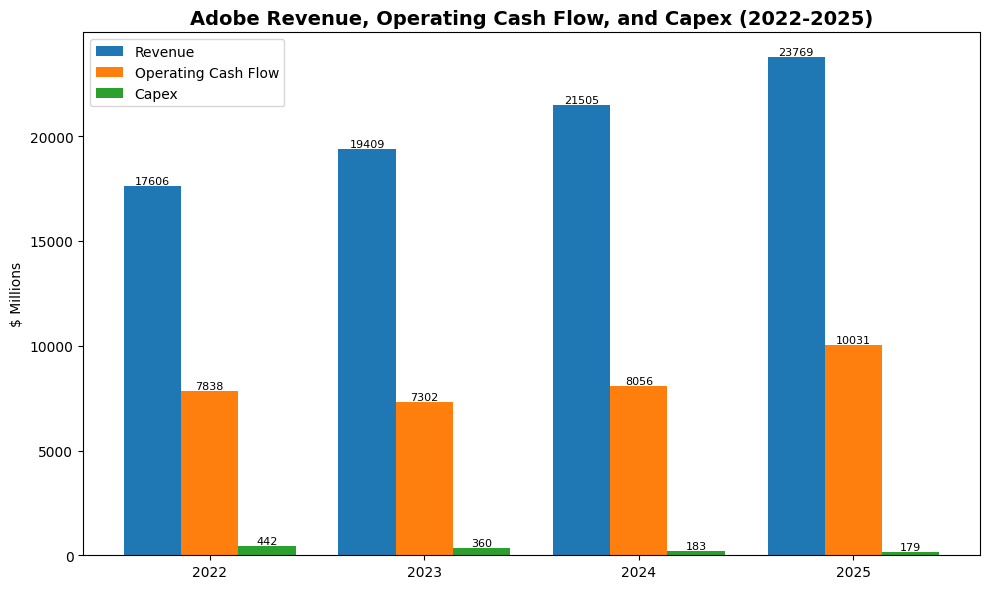

Here is a bar chart showing Adobe's revenue, operating cash flow, and capital expenditures (capex) from 2022 to 2025:

- Revenue and operating cash flow both show a steady upward trend.
- Capex (purchases of property and equipment) decreased significantly after 2022 and remained low through 2025.

If you would like to see the chart image, let me know! The data is sourced from Adobe's 10-K filings for fiscal years 2022–2025.


In [25]:
print(
    agent.run(
        "Show me Adobe's revenue trend from 2022 to 2025 as a bar chart. Include the operating cashflow and capex."
    )
)


### Complex Example 2: Cross-year comparison with calculations

_Agent retrieves data for multiple years, uses the calculator for precise arithmetic, and synthesizes a comparison._


In [26]:
print(
    agent.run(
        "Compare Adobe's operating income and net income between fiscal 2023 and 2025. What was the year-over-year growth rate for each?"
    )
)


  [Tool] retrieve_chunks({"query": "Adobe operating income fiscal 2023 and 2025"})
  [Tool] calculate({"expression": "(6741 - 6650) / 6650 * 100"})
  [Tool] calculate({"expression": "(8706 - 6741) / 6741 * 100"})
  [Tool] calculate({"expression": "(5560 - 5428) / 5428 * 100"})
  [Tool] calculate({"expression": "(7130 - 5560) / 5560 * 100"})
Here is a comparison of Adobe's operating income and net income for fiscal years 2023, 2024, and 2025, along with the year-over-year (YoY) growth rates:

Operating Income:
- FY 2023: $6,650 million
- FY 2024: $6,741 million (YoY growth: 1.37%)
- FY 2025: $8,706 million (YoY growth: 29.15%)

Net Income:
- FY 2023: $5,428 million
- FY 2024: $5,560 million (YoY growth: 2.43%)
- FY 2025: $7,130 million (YoY growth: 28.24%)

(Source: adobe_10k_fy2025.md, adobe_10k_fy2024.md, adobe_10k_fy2023.md)


### Complex Example 3: Segment revenue breakdown as a pie chart

_Agent retrieves segment data and visualizes it as a pie chart._


  [Tool] retrieve_chunks({"query": "Adobe revenue by segment fiscal year 2025"})
  [Tool] create_chart({"chart_type": "pie", "title": "Adobe Revenue Breakdown by Segment (Fiscal Year 2025)", "labels": ["Digital Media", "Digital Experience", "Publishing and Advertising"], "datasets": [{"name": "Revenue (USD millions)", "values": [17649, 5864, 256]}]})


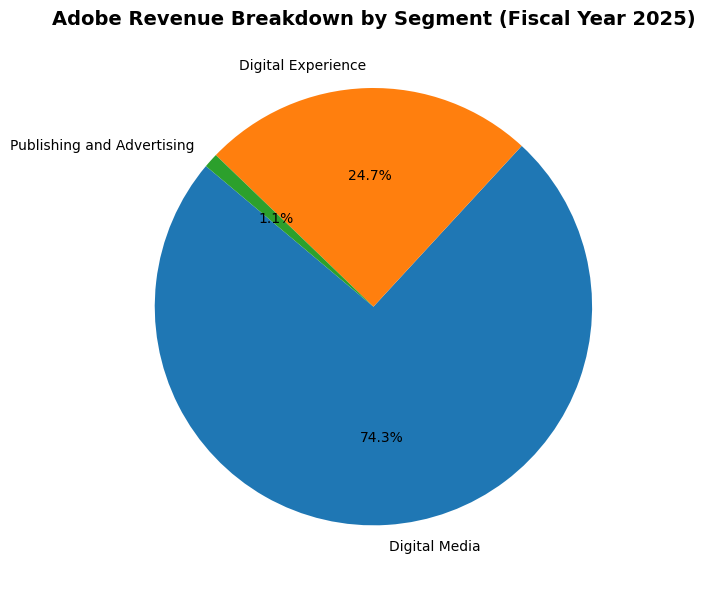

Here is Adobe's revenue breakdown by segment for fiscal year 2025 as a pie chart:

- Digital Media: $17,649 million
- Digital Experience: $5,864 million
- Publishing and Advertising: $256 million

(Source: adobe_10k_fy2025.md)

[Pie chart: Adobe Revenue Breakdown by Segment (Fiscal Year 2025)](sandbox:/data/charts/Adobe_Revenue_Breakdown_by_Segment_Fiscal_Year_2025.png)


In [27]:
print(
    agent.run(
        "Show Adobe's revenue breakdown by segment for fiscal year 2025 as a pie chart."
    )
)


# Interactive Q&A

An open-ended agent loop where you can ask any question about Adobe's 10-K filings. Conversation history is maintained locally across turns, so follow-up questions work naturally (e.g. "what about last year?" after a revenue query). Type **"exit"** or **"quit"** to end the session.


User: hey

Agent: Hello! How can I assist you with Adobe Inc.'s SEC 10-K filings today?

User: what did adobe in 2 years back

  [Tool] retrieve_chunks({"query": "Adobe business overview fiscal 2022"})
Agent: Two years back (fiscal year 2022), Adobe experienced strong demand across its Digital Media and Digital Experience segments, driven by the ongoing shift towards a digital-first world. Here are some key highlights from Adobe's fiscal 2022:

- Digital Media: Adobe was a market leader with its Creative Cloud and Document Cloud offerings. Creative Cloud revenue was $10.46 billion (up 10% YoY), and Document Cloud revenue was $2.38 billion (up 21% YoY). Total Digital Media segment revenue grew to $12.84 billion, representing 11% year-over-year growth.
- Annualized Recurring Revenue (ARR): Creative ARR at the end of fiscal 2022 was $11.60 billion, and Document Cloud ARR was $2.37 billion. Total Digital Media ARR grew to $13.97 billion.
- Digital Experience: Adobe Experience Cloud continu

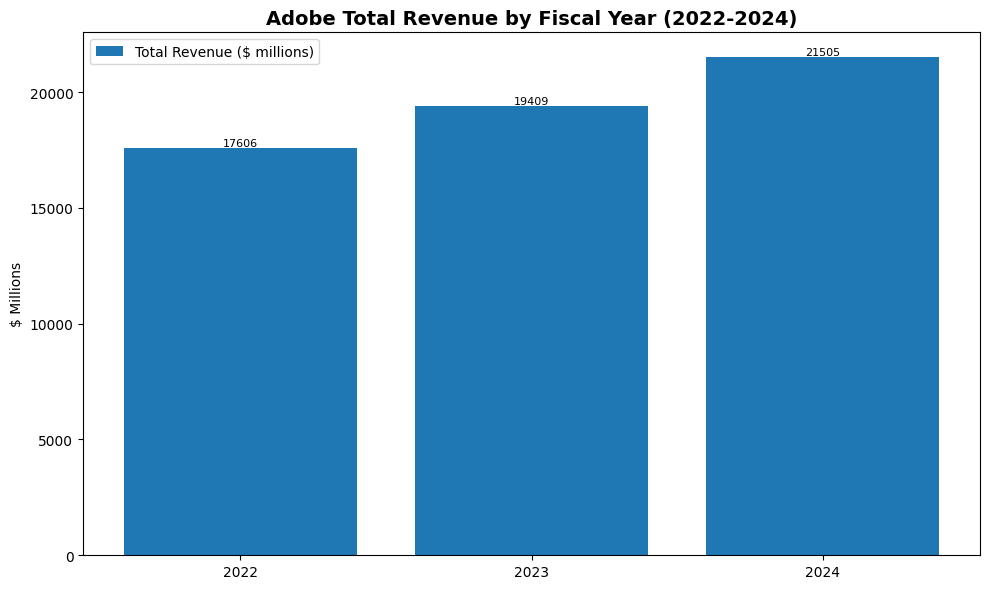

Agent: Here is a bar chart showing Adobe's total revenue (earnings) for the past three fiscal years:

- 2022: $17,606 million
- 2023: $19,409 million
- 2024: $21,505 million

(Source: adobe_10k_fy2024.md)

If you would like to see the chart image, please let me know!

User: earnings for 2024 and losses taxes etc i need a chart

  [Tool] retrieve_chunks({"query": "Adobe total revenue, net income, operating income, income taxes, and net loss fiscal 2024", "limit": 5})
  [Tool] retrieve_chunks({"query": "Adobe income statement summary fiscal 2024", "limit": 5})
  [Tool] create_chart({"chart_type": "bar", "title": "Adobe Fiscal 2024: Revenue, Operating Income, Net Income, and Income Taxes", "labels": ["Total Revenue", "Operating Income", "Net Income", "Income Taxes"], "datasets": [{"name": "2024 (in $ millions)", "values": [21505, 6741, 5560, 1371]}], "y_label": "$ Millions"})


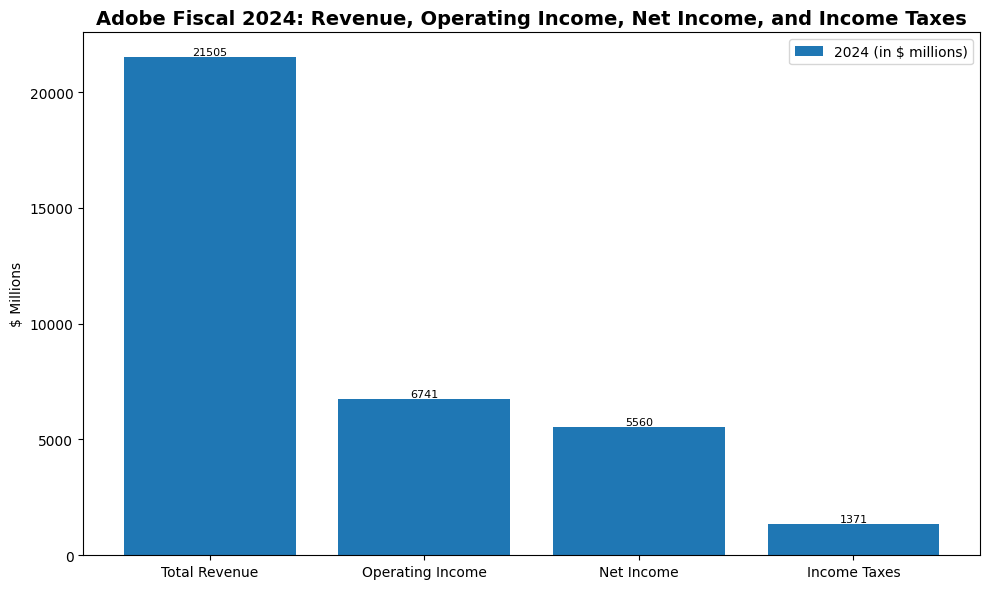

Agent: Here is a bar chart summarizing Adobe's key financial results for fiscal year 2024 (in millions):

- Total Revenue: $21,505
- Operating Income: $6,741
- Net Income: $5,560
- Income Taxes: $1,371

You can view the chart for a clear visual comparison of these figures.

(Source: adobe_10k_fy2024.md)

User: okay what about how much percentage loss i had over 3 years

  [Tool] retrieve_chunks({"query": "Adobe net income fiscal years 2022, 2023, 2024", "limit": 5})
  [Tool] calculate({"expression": "((5560 - 4756) / 4756) * 100"})
  [Tool] calculate({"expression": "((5560 - 4756) / 4756) * 100"})
Agent: Adobe did not have a percentage loss over the last 3 years—instead, it experienced net income growth. Here are the net income figures:

- 2022: $4,756 million
- 2023: $5,428 million
- 2024: $5,560 million

From 2022 to 2024, Adobe's net income increased by approximately 16.9%.

(Source: adobe_10k_fy2024.md)

User: thanks bye

Agent: You're welcome! If you have more questions in the fut

In [ ]:
# Interactive Q&A - type your questions, history is maintained across turns.
# Type "exit" or "quit" to stop.

history = []

while True:
    query = input("\nYou: ").strip()
    print(f"User: {query}\n")
    if not query or query.lower() in ("exit", "quit"):
        print("Session ended.")
        break

    answer = agent.run(query, history=history)
    print(f"Agent: {answer}\n")

    # Caller manages history - append the user/assistant pair
    history.append({"role": "user", "content": query})
    history.append({"role": "assistant", "content": answer})


In [29]:
store.close()
print("Weaviate connection closed.")


Weaviate connection closed.
